# Model ablation head-to-head comparison

This notebook performs repository-aware ablation comparison for:
- `PointNetMLPJoint`
- `PointNetMLPJoint_headfeat`
- `ArGEnT_self_att_noSDF`

Across `Uniform/` and `Zonal/`, with explicit coverage and exclusions.


## Design choices used here

- Checkpoints are discovered only from `**/Trained_models/*.pt` under `Uniform/` and `Zonal/`.
- Architecture reconstruction is done from code in the **same model directory as each checkpoint**.
- Canonical presets are read from repo shell launchers (`run0.sh`, `run1.sh`) and mapped to each folder.
- Evaluation split reproduces training scripts (`train_test_split(..., test_size=0.2, random_state=42)`) and evaluates on **validation split**.
- If datasets/checkpoints/code are missing or inconsistent, entries are reported in **Coverage and exclusions**.


In [29]:
from __future__ import annotations

import ast
import contextlib
import importlib.util
import inspect
import json
import math
import os
import re
import sys
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

try:
    import torch
except Exception:
    torch = None

try:
    import h5py
except Exception:
    h5py = None

try:
    from sklearn.model_selection import train_test_split
except Exception:
    train_test_split = None

import matplotlib.pyplot as plt
import seaborn as sns
current_dir =  Path(
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)

pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')


In [30]:
REPO_ROOT = current_dir.parent
if not (REPO_ROOT / 'Uniform').exists() or not (REPO_ROOT / 'Zonal').exists():
    raise RuntimeError('Run this notebook from repository root.')

COMPARISON_DIR = REPO_ROOT / 'Comparison'
FIG_DIR = COMPARISON_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_FAMILIES = [
    'PointNetMLPJoint',
    'PointNetMLPJoint_headfeat',
    'ArGEnT_self_att_noSDF',
]

RUN_SCRIPTS = [REPO_ROOT / 'run0.sh', REPO_ROOT / 'run1.sh']


In [31]:
def parse_training_constants(training_script: Path) -> Dict[str, Any]:
    txt = training_script.read_text(encoding='utf-8')
    tree = ast.parse(txt)
    wanted = {
        'TARGET_NAMES', 'INPUT_COLS', 'H5_FILENAME', 'EXPECTED_REPR',  # EXPECTED_REPR = expected H5 representation
        'QUERY_COLS', 'NUM_TARGETS'
    }
    out: Dict[str, Any] = {}
    for node in tree.body:
        if isinstance(node, ast.AnnAssign) and isinstance(node.target, ast.Name):
            name = node.target.id
            if name in wanted and node.value is not None:
                try:
                    out[name] = ast.literal_eval(node.value)
                except Exception:
                    pass
        elif isinstance(node, ast.Assign):
            for t in node.targets:
                if isinstance(t, ast.Name) and t.id in wanted:
                    try:
                        out[t.id] = ast.literal_eval(node.value)
                    except Exception:
                        pass
    if 'NUM_TARGETS' not in out and isinstance(out.get('TARGET_NAMES'), list):
        out['NUM_TARGETS'] = len(out['TARGET_NAMES'])
    return out


def parse_run_script_presets(path: Path) -> pd.DataFrame:
    rows = []
    if not path.exists():
        return pd.DataFrame(columns=["training_dir", "preset", "launcher", "run_script", "line_no"])

    text = path.read_text(encoding="utf-8")
    pat = re.compile(
        r"python\s+-u\s+"
        r"(?P<launcher>Disc_lifing_paper/(?P<training_dir>(?:Uniform|Zonal)/[^\s/]+/[^\s/]+)/(?:GPUL2|GPU0)\.py)"
        r"(?:\s+|.*?\s)--preset\s+(?P<preset>[^\s]+)"
    )

    for ln, line in enumerate(text.splitlines(), start=1):
        m = pat.search(line)
        if not m:
            continue
        rows.append({
            "training_dir": m.group("training_dir"),
            "preset": m.group("preset"),
            "launcher": m.group("launcher"),
            "run_script": path.name,
            "line_no": ln,
        })

    return pd.DataFrame(rows)


def discover_training_dirs() -> pd.DataFrame:
    rows = []
    for regime in ['Uniform', 'Zonal']:
        base = REPO_ROOT / regime
        if not base.exists():
            continue
        for ablation_dir in sorted([p for p in base.iterdir() if p.is_dir()]):
            for fam_dir in sorted([p for p in ablation_dir.iterdir() if p.is_dir()]):
                if fam_dir.name not in TARGET_FAMILIES:
                    continue
                ts = fam_dir / 'Training_script.py'
                rows.append({
                    'regime': regime,
                    'ablation': ablation_dir.name,
                    'model_family': fam_dir.name,
                    'training_dir': str(fam_dir.relative_to(REPO_ROOT)),
                    'training_script': str(ts.relative_to(REPO_ROOT)) if ts.exists() else None,
                    'training_script_exists': ts.exists(),
                    'trained_models_dir': str((fam_dir / 'Trained_models').relative_to(REPO_ROOT)),
                    'trained_models_dir_exists': (fam_dir / 'Trained_models').exists(),
                })
    return pd.DataFrame(rows)

def normalize_training_dir_col(df: pd.DataFrame, col: str = "training_dir") -> pd.DataFrame:
    out = df.copy()
    out[col] = (
        out[col]
        .astype(str)
        .str.replace("\\", "/", regex=False)
        .str.strip()
        .str.replace(r"/+", "/", regex=True)
    )
    return out


def discover_checkpoints() -> pd.DataFrame:
    rows = []
    for regime in ("Uniform", "Zonal"):
        base = REPO_ROOT / regime
        if not base.exists():
            continue

        for ckpt in sorted(base.glob("*/*/Trained_models/*.pt")):
            rel = ckpt.relative_to(REPO_ROOT)
            parts = rel.parts
            if len(parts) != 5:
                continue

            rows.append({
                "regime": parts[0],
                "ablation": parts[1],
                "model_family": parts[2],
                "training_dir": str(Path(parts[0]) / parts[1] / parts[2]),
                "checkpoint_path": str(rel),
                "checkpoint_filename": parts[4],
                "exists": True,
            })

    return pd.DataFrame(rows)


In [32]:
train_dirs_df = normalize_training_dir_col(discover_training_dirs(), "training_dir")
ckpt_df = normalize_training_dir_col(discover_checkpoints(), "training_dir")
run_preset_df = normalize_training_dir_col(
    pd.concat([parse_run_script_presets(p) for p in RUN_SCRIPTS], ignore_index=True),
    "training_dir"
)
parts = run_preset_df["training_dir"].str.split("/", expand=True)
run_preset_df["regime"] = parts[0]
run_preset_df["ablation"] = parts[1]
run_preset_df["model_family"] = parts[2]

inv_df = train_dirs_df.merge(
    run_preset_df[["regime", "ablation", "model_family", "preset", "run_script"]].drop_duplicates(),
    on=["regime", "ablation", "model_family"],
    how="left",
)

manifest_df = inv_df.merge(
    ckpt_df,
    on=["regime", "ablation", "model_family", "training_dir"],
    how="left",
)

manifest_df["exists"] = manifest_df["exists"].fillna(False)
manifest_df = manifest_df.sort_values(
    ["regime", "ablation", "model_family", "checkpoint_filename"],
    na_position="last",
).reset_index(drop=True)

print(f"Training dirs discovered: {len(train_dirs_df)}")
print(f"Checkpoints discovered: {len(ckpt_df)}")
print(f"Launcher preset mappings: {len(run_preset_df)}")

display(
    manifest_df[
        ["regime", "ablation", "model_family", "training_dir", "preset", "checkpoint_filename", "exists"]
    ]
)

Training dirs discovered: 31
Checkpoints discovered: 27
Launcher preset mappings: 31


,regime,ablation,model_family,training_dir,preset,checkpoint_filename,exists
0,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform/Edge/ArGEnT_self_att_noSDF,S,argent_self_nosdf_s_177b264d.pt,True
1,Uniform,Edge,PointNetMLPJoint,Uniform/Edge/PointNetMLPJoint,S_full_ln_pos8,pn_s_full_ln_pos8_242ec847.pt,True
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform/Edge_Prox/ArGEnT_self_att_noSDF,S,argent_self_nosdf_s_177b264d.pt,True
3,Uniform,Edge_Prox,PointNetMLPJoint,Uniform/Edge_Prox/PointNetMLPJoint,S_full_ln_pos8,pn_s_full_ln_pos8_25b849a3.pt,True
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Uniform/Edge_arc/ArGEnT_self_att_noSDF,S,argent_self_nosdf_s_dea33a7e.pt,True
5,Uniform,Edge_arc,PointNetMLPJoint,Uniform/Edge_arc/PointNetMLPJoint,S_full_ln_pos8,pn_s_full_ln_pos8_242ec847.pt,True
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,Uniform/Edge_arc/PointNetMLPJoint_headfeat,S_full_ln_pos8,pn_s_full_ln_pos8_76cc6623.pt,True
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,Uniform/Edge_arc_feat/ArGEnT_self_att_noSDF,S,argent_self_nosdf_s_62997625.pt,True
8,Uniform,Edge_arc_feat,PointNetMLPJoint,Uniform/Edge_arc_feat/PointNetMLPJoint,S_full_ln_pos8,pn_s_full_ln_pos8_242ec847.pt,True
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,Uniform/Edge_arc_feat/PointNetMLPJoint_headfeat,S_full_ln_pos8,pn_s_full_ln_pos8_76cc6623.pt,True


## 1) Repo discovery manifest (all discovered checkpoints under Trained_models)


In [33]:
manifest_df[['regime','ablation','model_family','training_dir','preset','checkpoint_path','checkpoint_filename','exists']]


,regime,ablation,model_family,training_dir,preset,checkpoint_path,checkpoint_filename,exists
0,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform/Edge/ArGEnT_self_att_noSDF,S,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,argent_self_nosdf_s_177b264d.pt,True
1,Uniform,Edge,PointNetMLPJoint,Uniform/Edge/PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,pn_s_full_ln_pos8_242ec847.pt,True
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform/Edge_Prox/ArGEnT_self_att_noSDF,S,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,argent_self_nosdf_s_177b264d.pt,True
3,Uniform,Edge_Prox,PointNetMLPJoint,Uniform/Edge_Prox/PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,pn_s_full_ln_pos8_25b849a3.pt,True
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Uniform/Edge_arc/ArGEnT_self_att_noSDF,S,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,argent_self_nosdf_s_dea33a7e.pt,True
5,Uniform,Edge_arc,PointNetMLPJoint,Uniform/Edge_arc/PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,pn_s_full_ln_pos8_242ec847.pt,True
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,Uniform/Edge_arc/PointNetMLPJoint_headfeat,S_full_ln_pos8,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,pn_s_full_ln_pos8_76cc6623.pt,True
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,Uniform/Edge_arc_feat/ArGEnT_self_att_noSDF,S,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt,argent_self_nosdf_s_62997625.pt,True
8,Uniform,Edge_arc_feat,PointNetMLPJoint,Uniform/Edge_arc_feat/PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,pn_s_full_ln_pos8_242ec847.pt,True
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,Uniform/Edge_arc_feat/PointNetMLPJoint_headfeat,S_full_ln_pos8,Uniform\Edge_arc_feat\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,pn_s_full_ln_pos8_76cc6623.pt,True


In [34]:
# Expected coverage summary (including missing checkpoints)
coverage_counts = manifest_df.groupby(['regime','ablation','model_family'], dropna=False).agg(
    n_checkpoints=('checkpoint_path', lambda s: int(s.notna().sum())),
    has_checkpoint=('exists', 'max'),
    preset=('preset', 'first'),
).reset_index()
coverage_counts = coverage_counts.sort_values(['regime','ablation','model_family']).reset_index(drop=True)
coverage_counts


,regime,ablation,model_family,n_checkpoints,has_checkpoint,preset
0,Uniform,Edge,ArGEnT_self_att_noSDF,1,True,S
1,Uniform,Edge,PointNetMLPJoint,1,True,S_full_ln_pos8
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,1,True,S
3,Uniform,Edge_Prox,PointNetMLPJoint,1,True,S_full_ln_pos8
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,1,True,S
5,Uniform,Edge_arc,PointNetMLPJoint,1,True,S_full_ln_pos8
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,1,True,S_full_ln_pos8
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,1,True,S
8,Uniform,Edge_arc_feat,PointNetMLPJoint,1,True,S_full_ln_pos8
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,1,True,S_full_ln_pos8


In [35]:
def choose_primary_checkpoint(group: pd.DataFrame) -> Optional[str]:
    # Prefer checkpoint matching model_name for launcher preset, fallback to first existing.
    rows = group[group['checkpoint_path'].notna()].copy()
    if rows.empty:
        return None

    training_dir = rows['training_dir'].iloc[0]
    preset = rows['preset'].dropna().iloc[0] if rows['preset'].notna().any() else None
    model_name = None
    if preset:
        mp = REPO_ROOT / training_dir / 'model_presets.json'
        if mp.exists():
            try:
                cfg = json.loads(mp.read_text(encoding='utf-8'))
                if isinstance(cfg, dict) and preset in cfg and isinstance(cfg[preset], dict):
                    model_name = cfg[preset].get('model_name')
            except Exception:
                pass
    if model_name:
        pref = rows[rows['checkpoint_filename'].str.startswith(f"{model_name}_")]
        if not pref.empty:
            return pref.sort_values('checkpoint_filename').iloc[0]['checkpoint_path']
    return rows.sort_values('checkpoint_filename').iloc[0]['checkpoint_path']

primary_ckpt_rows = []
for _, g in manifest_df.groupby(['regime','ablation','model_family'], dropna=False):
    p = choose_primary_checkpoint(g)
    base = g.iloc[0].to_dict()
    base['primary_checkpoint_path'] = p
    primary_ckpt_rows.append(base)

primary_df = pd.DataFrame(primary_ckpt_rows)
primary_df = primary_df[['regime','ablation','model_family','training_dir','training_script','preset','primary_checkpoint_path']].sort_values(['regime','ablation','model_family']).reset_index(drop=True)
primary_df


,regime,ablation,model_family,training_dir,training_script,preset,primary_checkpoint_path
0,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform/Edge/ArGEnT_self_att_noSDF,Uniform\Edge\ArGEnT_self_att_noSDF\Training_script.py,S,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt
1,Uniform,Edge,PointNetMLPJoint,Uniform/Edge/PointNetMLPJoint,Uniform\Edge\PointNetMLPJoint\Training_script.py,S_full_ln_pos8,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform/Edge_Prox/ArGEnT_self_att_noSDF,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Training_script.py,S,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt
3,Uniform,Edge_Prox,PointNetMLPJoint,Uniform/Edge_Prox/PointNetMLPJoint,Uniform\Edge_Prox\PointNetMLPJoint\Training_script.py,S_full_ln_pos8,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Uniform/Edge_arc/ArGEnT_self_att_noSDF,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Training_script.py,S,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt
5,Uniform,Edge_arc,PointNetMLPJoint,Uniform/Edge_arc/PointNetMLPJoint,Uniform\Edge_arc\PointNetMLPJoint\Training_script.py,S_full_ln_pos8,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,Uniform/Edge_arc/PointNetMLPJoint_headfeat,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Training_script.py,S_full_ln_pos8,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,Uniform/Edge_arc_feat/ArGEnT_self_att_noSDF,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Training_script.py,S,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt
8,Uniform,Edge_arc_feat,PointNetMLPJoint,Uniform/Edge_arc_feat/PointNetMLPJoint,Uniform\Edge_arc_feat\PointNetMLPJoint\Training_script.py,S_full_ln_pos8,Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,Uniform/Edge_arc_feat/PointNetMLPJoint_headfeat,Uniform\Edge_arc_feat\PointNetMLPJoint_headfeat\Training_script.py,S_full_ln_pos8,Uniform\Edge_arc_feat\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt


## 2) Architecture-aware checkpoint inspection


In [36]:
def torch_available() -> bool:
    return torch is not None


def load_checkpoint_cpu(path: Path) -> Dict[str, Any]:
    if torch is None:
        raise RuntimeError('torch is not installed in this environment')
    return torch.load(path, map_location='cpu')


def summarize_checkpoint_meta(row: pd.Series) -> Dict[str, Any]:
    out = {
        'training_dir': row['training_dir'],
        'checkpoint_path': row['checkpoint_path'],
        'checkpoint_filename': row.get('checkpoint_filename'),
        'load_ok': False,
        'error': None,
        'model_name': None,
        'arch_present': False,
        'arch_keys': None,
        'target_names_ckpt': None,
        'target_names_script': None,
        'extra_feat_cols': None,
        'head_feat_cols': None,
        'head_feat_dim_arch': None,
        'normalization_keys_present': None,
        'reconstructable': False,
        'reconstruct_reason': None,
    }

    training_dir = REPO_ROOT / row['training_dir']
    ts_path = training_dir / 'Training_script.py'
    script_cfg = parse_training_constants(ts_path) if ts_path.exists() else {}
    out['target_names_script'] = script_cfg.get('TARGET_NAMES')

    if not row.get('checkpoint_path'):
        out['error'] = 'missing checkpoint'
        out['reconstruct_reason'] = 'missing checkpoint'
        return out

    p = REPO_ROOT / row['checkpoint_path']
    if not p.exists():
        out['error'] = 'checkpoint file missing on disk'
        out['reconstruct_reason'] = 'checkpoint file missing on disk'
        return out

    if torch is None:
        out['error'] = 'torch unavailable: cannot inspect checkpoint in this runtime'
        out['reconstruct_reason'] = out['error']
        return out

    try:
        ckpt = load_checkpoint_cpu(p)
        out['load_ok'] = True
        out['model_name'] = ckpt.get('model_name')
        arch = ckpt.get('arch')
        out['arch_present'] = isinstance(arch, dict)
        out['arch_keys'] = sorted(arch.keys()) if isinstance(arch, dict) else None
        out['target_names_ckpt'] = ckpt.get('target_names')
        out['extra_feat_cols'] = ckpt.get('extra_feat_cols')
        out['head_feat_cols'] = ckpt.get('head_feat_cols')
        out['head_feat_dim_arch'] = arch.get('head_feat_dim') if isinstance(arch, dict) else None

        norm_keys = ['coord_center','coord_half_range','target_mean','target_std','extra_feat_stats']
        out['normalization_keys_present'] = {k: (k in ckpt) for k in norm_keys}

        has_state = isinstance(ckpt.get('model_state'), dict)
        fam = row['model_family']
        code_ok = (training_dir / 'pn_models.py').exists() if fam.startswith('PointNetMLPJoint') else (training_dir / 'benchmarks.py').exists()

        if not has_state:
            out['reconstruct_reason'] = 'model_state missing'
        elif not code_ok:
            out['reconstruct_reason'] = 'required local model code file missing'
        elif not isinstance(arch, dict):
            out['reconstruct_reason'] = 'arch missing/not-dict'
        else:
            out['reconstructable'] = True
            out['reconstruct_reason'] = 'ok'
    except Exception as e:
        out['error'] = f'{type(e).__name__}: {e}'
        out['reconstruct_reason'] = out['error']

    return out


ckpt_meta_rows = []
for _, r in manifest_df[manifest_df['checkpoint_path'].notna()].iterrows():
    ckpt_meta_rows.append(summarize_checkpoint_meta(r))

ckpt_meta_df = pd.DataFrame(ckpt_meta_rows)
ckpt_meta_df


,training_dir,checkpoint_path,checkpoint_filename,load_ok,error,model_name,arch_present,arch_keys,target_names_ckpt,target_names_script,extra_feat_cols,head_feat_cols,head_feat_dim_arch,normalization_keys_present,reconstructable,reconstruct_reason
0,Uniform/Edge/ArGEnT_self_att_noSDF,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,argent_self_nosdf_s_177b264d.pt,True,None,NaN,True,"[attention_type, hidden_dim, in_ch_geom, num_heads, num_layers, out_channels, output_dim, use_sdf]",None,"[Stress, LogLife]",[],None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
1,Uniform/Edge/PointNetMLPJoint,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,pn_s_full_ln_pos8_242ec847.pt,True,None,pn_s_full_ln_pos8,True,"[encoder_cfg, head_hidden, out_dim]",None,"[Stress, LogLife]","[2, 3, 4, 5, 6, 7]",None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
2,Uniform/Edge_Prox/ArGEnT_self_att_noSDF,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,argent_self_nosdf_s_177b264d.pt,True,None,NaN,True,"[attention_type, hidden_dim, in_ch_geom, num_heads, num_layers, out_channels, output_dim, use_sdf]",None,"[Stress, LogLife]",[],None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
3,Uniform/Edge_Prox/PointNetMLPJoint,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,pn_s_full_ln_pos8_25b849a3.pt,True,None,pn_s_full_ln_pos8,True,"[encoder_cfg, head_hidden, out_dim]",None,"[Stress, LogLife]",[2],None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
4,Uniform/Edge_arc/ArGEnT_self_att_noSDF,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,argent_self_nosdf_s_dea33a7e.pt,True,None,NaN,True,"[attention_type, hidden_dim, in_ch_geom, num_heads, num_layers, out_channels, output_dim, use_sdf]",None,"[Stress, LogLife]",[],None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
5,Uniform/Edge_arc/PointNetMLPJoint,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,pn_s_full_ln_pos8_242ec847.pt,True,None,pn_s_full_ln_pos8,True,"[encoder_cfg, head_hidden, out_dim]",None,"[Stress, LogLife]","[2, 3, 4, 5, 6, 7]",None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
6,Uniform/Edge_arc/PointNetMLPJoint_headfeat,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,pn_s_full_ln_pos8_76cc6623.pt,True,None,pn_s_full_ln_pos8,True,"[encoder_cfg, head_feat_dim, head_hidden, out_dim]",None,"[Stress, LogLife]","[2, 3, 4, 5, 6, 7]","[2, 3, 4, 5, 6, 7]",6.0,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
7,Uniform/Edge_arc_feat/ArGEnT_self_att_noSDF,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt,argent_self_nosdf_s_62997625.pt,True,None,NaN,True,"[attention_type, hidden_dim, in_ch_geom, num_heads, num_layers, out_channels, output_dim, use_sdf]",None,"[Stress, LogLife]",[],None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': True, 'extra_feat_stats': True}",True,ok
8,Uniform/Edge_arc_feat/PointNetMLPJoint,Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,pn_s_full_ln_pos8_242ec847.pt,True,None,pn_s_full_ln_pos8,True,"[encoder_cfg, head_hidden, out_dim]",None,"[Stress, LogLife]","[2, 3, 4, 5, 6, 7]",None,NaN,"{'coord_center': True, 'coord_half_range': True, 'target_mean': True, 'target_std': 

In [37]:
if ckpt_meta_df.empty:
    print('No checkpoints found.')
else:
    cols = [
        'training_dir','checkpoint_filename','load_ok','model_name','arch_present',
        'extra_feat_cols','head_feat_cols','head_feat_dim_arch','target_names_script',
        'reconstructable','reconstruct_reason','error'
    ]
    ckpt_meta_df[cols].sort_values(['training_dir','checkpoint_filename'])


## 3) Reconstruction using local code from same checkpoint directory


In [40]:
@contextlib.contextmanager
def prepend_sys_path(path: Path):
    p = str(path)
    sys.path.insert(0, p)
    try:
        yield
    finally:
        if p in sys.path:
            sys.path.remove(p)


def import_module_from_file(module_name: str, file_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    if spec is None or spec.loader is None:
        raise RuntimeError(f'Cannot import {file_path}')
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


def reconstruct_model_from_checkpoint(training_dir: Path, model_family: str, ckpt: Dict[str, Any]):
    arch = ckpt.get('arch')
    if not isinstance(arch, dict):
        raise RuntimeError('Checkpoint arch is missing or not a dict')

    with prepend_sys_path(training_dir):
        if model_family.startswith('PointNetMLPJoint'):
            pn = import_module_from_file(f"pn_models_{training_dir.name}", training_dir / 'pn_models.py')
            if hasattr(pn, 'build_model_from_arch'):
                model = pn.build_model_from_arch(arch)
            else:
                # fallback constructor
                model = pn.PointNetMLPJoint(
                    latent_dim=int(arch.get('encoder_cfg', {}).get('latent_dim', 128)),
                    mlp_hidden=arch.get('head_hidden', [256, 256, 128]),
                    out_dim=int(arch.get('out_dim', 1)),
                    encoder_cfg=arch.get('encoder_cfg', None),
                    in_channels=int(arch.get('encoder_cfg', {}).get('in_channels', 0)),
                )
        elif model_family == 'ArGEnT_self_att_noSDF':
            bench = import_module_from_file(f"benchmarks_{training_dir.name}", training_dir / 'benchmarks.py')
            cls = getattr(bench, 'ArGEnTDeepONet')
            sig = inspect.signature(cls)
            kwargs = {k: v for k, v in arch.items() if k in sig.parameters}
            model = cls(**kwargs)
        else:
            raise RuntimeError(f'Unsupported model family: {model_family}')

    model.load_state_dict(ckpt['model_state'], strict=True)
    model.eval()
    return model


recon_rows = []
if torch is None:
    print('torch is not installed in this runtime; reconstruction test skipped here.')
else:
    for _, row in primary_df.iterrows():
        status = {
            'regime': row['regime'],
            'ablation': row['ablation'],
            'model_family': row['model_family'],
            'training_dir': row['training_dir'],
            'primary_checkpoint_path': row['primary_checkpoint_path'],
            'reconstruction_ok': False,
            'reconstruction_error': None,
        }
        if not isinstance(row['primary_checkpoint_path'], str):
            status['reconstruction_error'] = 'no selected checkpoint'
            recon_rows.append(status)
            continue
        try:
            ckpt = load_checkpoint_cpu(REPO_ROOT / row['primary_checkpoint_path'])
            _m = reconstruct_model_from_checkpoint(REPO_ROOT / row['training_dir'], row['model_family'], ckpt)
            status['reconstruction_ok'] = True
        except Exception as e:
            status['reconstruction_error'] = f'{type(e).__name__}: {e}'
        recon_rows.append(status)

recon_df = pd.DataFrame(recon_rows)
recon_df if not recon_df.empty else pd.DataFrame(columns=['No reconstruction attempted'])


,regime,ablation,model_family,training_dir,primary_checkpoint_path,reconstruction_ok,reconstruction_error
0,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform/Edge/ArGEnT_self_att_noSDF,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,NaN
1,Uniform,Edge,PointNetMLPJoint,Uniform/Edge/PointNetMLPJoint,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,NaN
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform/Edge_Prox/ArGEnT_self_att_noSDF,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,NaN
3,Uniform,Edge_Prox,PointNetMLPJoint,Uniform/Edge_Prox/PointNetMLPJoint,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,True,NaN
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Uniform/Edge_arc/ArGEnT_self_att_noSDF,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,True,NaN
5,Uniform,Edge_arc,PointNetMLPJoint,Uniform/Edge_arc/PointNetMLPJoint,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,NaN
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,Uniform/Edge_arc/PointNetMLPJoint_headfeat,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,True,NaN
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,Uniform/Edge_arc_feat/ArGEnT_self_att_noSDF,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt,True,NaN
8,Uniform,Edge_arc_feat,PointNetMLPJoint,Uniform/Edge_arc_feat/PointNetMLPJoint,Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,NaN
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,Uniform/Edge_arc_feat/PointNetMLPJoint_headfeat,Uniform\Edge_arc_feat\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,True,NaN


## 4) Dataset/split handling and evaluation functions


In [45]:
def load_h5_pointsets(path: Path) -> List[np.ndarray]:
    if h5py is None:
        raise RuntimeError('h5py is not installed')
    sets = []
    with h5py.File(path, 'r') as f:
        if 'samples' not in f:
            raise RuntimeError(f"'samples' group missing in {path}")
        for name in sorted(f['samples'].keys()):
            grp = f['samples'][name]
            coords = grp['node_coords_mm'][:]
            zone_id = grp['zone_id'][:].astype(np.float32)
            stress = grp['stress_max_vm'][:].astype(np.float32)
            life = grp['life_raw'][:].astype(np.float32)

            cols = [coords[:, 0].astype(np.float32), coords[:, 1].astype(np.float32), zone_id]
            if 'arc_length_mm' in grp:
                arc = grp['arc_length_mm'][:].astype(np.float32)
                if not np.any(np.isnan(arc)):
                    cols.append(arc)

            node_features = grp['node_features'][:]
            if node_features.ndim == 2 and node_features.shape[1] > 0:
                for i in range(node_features.shape[1]):
                    cols.append(node_features[:, i].astype(np.float32))

            life_log10 = np.log10(life).astype(np.float32)
            cols.append(stress)
            cols.append(life_log10)

            sets.append(np.stack(cols, axis=-1).astype(np.float32))
    return sets


def split_indices(n: int, test_size: float = 0.2, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """Return (train_indices, validation_indices)."""
    idx = np.arange(n)
    if train_test_split is not None:
        tr, va = train_test_split(idx, test_size=test_size, random_state=random_state)
        return np.array(tr), np.array(va)
    # fallback deterministic split
    rng = np.random.default_rng(random_state)
    perm = rng.permutation(idx)
    n_val = max(1, int(round(n * test_size)))
    return perm[n_val:], perm[:n_val]


SPLIT_SEED = 42
SPLIT_TEST_SIZE = 0.2
VALIDATION_SPLIT_CACHE: Dict[Tuple[str, int, float, int], np.ndarray] = {}


def get_shared_val_indices(dataset_key: str, n: int, test_size: float = SPLIT_TEST_SIZE, random_state: int = SPLIT_SEED) -> np.ndarray:
    """Guarantee identical validation indices for all models that use the same H5 dataset."""
    key = (dataset_key, int(n), float(test_size), int(random_state))
    if key not in VALIDATION_SPLIT_CACHE:
        _, val_idx = split_indices(n, test_size=test_size, random_state=random_state)
        VALIDATION_SPLIT_CACHE[key] = np.array(sorted(np.asarray(val_idx, dtype=int).tolist()), dtype=int)
    return VALIDATION_SPLIT_CACHE[key]


def to_numpy(x):
    if torch is not None and isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def get_target_slice(arr: np.ndarray, target_names: List[str]) -> np.ndarray:
    n_targets = len(target_names)
    if n_targets == 1:
        return arr[:, -1:]
    return arr[:, -n_targets:]


def map_target_name(name: str) -> str:
    s = str(name).strip().lower()
    if 'stress' in s:
        return 'Stress'
    if 'life' in s:
        return 'LogLife'
    return name


def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def r2(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot <= 1e-12:
        return float('nan')
    return 1.0 - ss_res / ss_tot


In [46]:
def evaluate_checkpoint_row(row: pd.Series) -> Dict[str, Any]:
    out = {
        'regime': row['regime'],
        'ablation': row['ablation'],
        'model_family': row['model_family'],
        'training_dir': row['training_dir'],
        'checkpoint_path': row.get('primary_checkpoint_path') or row.get('checkpoint_path'),
        'preset': row.get('preset'),
        'split_evaluated': 'val',
        'split_seed': SPLIT_SEED,
        'dataset_path': None,
        'dataset_exists': False,
        'evaluation_ok': False,
        'evaluation_error': None,
        'n_geometries_total': None,
        'n_geometries_eval': None,
        'target_names': None,
        'metrics': None,
    }

    if torch is None:
        out['evaluation_error'] = 'torch unavailable in this runtime'
        return out
    if h5py is None:
        out['evaluation_error'] = 'h5py unavailable in this runtime'
        return out
    
    ckpt_path = row.get('primary_checkpoint_path') or row.get('checkpoint_path')
    if not isinstance(ckpt_path, str):
        out['evaluation_error'] = 'no checkpoint selected'
        return out

    training_dir = REPO_ROOT / row['training_dir']
    ts_cfg = parse_training_constants(training_dir / 'Training_script.py')
    target_names = [map_target_name(t) for t in ts_cfg.get('TARGET_NAMES', [])]
    out['target_names'] = target_names
    h5_name = ts_cfg.get('H5_FILENAME')
    if not h5_name:
        out['evaluation_error'] = 'H5_FILENAME missing in training script constants'
        return out

    dataset_path = REPO_ROOT / 'Data_gen' / 'output' / h5_name
    dataset_key = str(dataset_path.relative_to(REPO_ROOT))
    out['dataset_path'] = dataset_key
    out['dataset_exists'] = dataset_path.exists()
    if not dataset_path.exists():
        out['evaluation_error'] = 'dataset file missing'
        return out

    try:
        ckpt = load_checkpoint_cpu(REPO_ROOT / ckpt_path)
        model = reconstruct_model_from_checkpoint(training_dir, row['model_family'], ckpt)

        arrays = load_h5_pointsets(dataset_path)
        out['n_geometries_total'] = len(arrays)
        val_idx = get_shared_val_indices(dataset_key, len(arrays), test_size=SPLIT_TEST_SIZE, random_state=SPLIT_SEED)
        val_arrays = [arrays[i] for i in val_idx]
        out['n_geometries_eval'] = len(val_arrays)

        # figure input columns from local training script (preferred), fallback checkpoint
        input_cols = ts_cfg.get('INPUT_COLS', [0, 1])
        query_cols = ts_cfg.get('QUERY_COLS', [0, 1])
        extra_feat_cols = ckpt.get('extra_feat_cols')
        head_feat_cols = ckpt.get('head_feat_cols')

        if row['model_family'] == 'ArGEnT_self_att_noSDF':
            feature_cols = list(input_cols)
        else:
            if isinstance(extra_feat_cols, list):
                feature_cols = list(extra_feat_cols)
            else:
                width0 = val_arrays[0].shape[1]
                feature_cols = list(range(2, width0 - 2))

        all_pred = []
        all_true = []
        n_targets = len(target_names)
        if n_targets == 0:
            # fallback
            n_targets = int(to_numpy(ckpt['target_mean']).reshape(-1).shape[0])
            target_names = [f'Target_{i}' for i in range(n_targets)]

        with torch.no_grad():
            for arr in val_arrays:
                target_true = get_target_slice(arr, target_names)

                if row['model_family'] == 'ArGEnT_self_att_noSDF':
                    enc = normalize_cols(arr, feature_cols, ckpt)
                    qry = normalize_cols(arr, list(query_cols), ckpt)
                    pred_norm = model(
                        torch.tensor(enc, dtype=torch.float32).unsqueeze(0),
                        torch.tensor(qry, dtype=torch.float32).unsqueeze(0),
                    ).squeeze(0).cpu().numpy()
                elif row['model_family'] == 'PointNetMLPJoint_headfeat':
                    xy = normalize_cols(arr, [0, 1], ckpt)
                    geom_feats = normalize_cols(arr, feature_cols, ckpt)
                    if isinstance(head_feat_cols, list):
                        hf_cols = list(head_feat_cols)
                    else:
                        hf_cols = feature_cols
                    head_feats = normalize_cols(arr, hf_cols, ckpt)
                    pred_norm = model(
                        torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                        torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                        torch.tensor(geom_feats, dtype=torch.float32).unsqueeze(0),
                        torch.tensor(head_feats, dtype=torch.float32).unsqueeze(0),
                    ).squeeze(0).cpu().numpy()
                else:
                    xy = normalize_cols(arr, [0, 1], ckpt)
                    geom_feats = normalize_cols(arr, feature_cols, ckpt)
                    pred_norm = model(
                        torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                        torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                        torch.tensor(geom_feats, dtype=torch.float32).unsqueeze(0),
                    ).squeeze(0).cpu().numpy()

                pred_raw = denorm_targets(pred_norm, ckpt, n_targets)
                if pred_raw.shape[-1] != target_true.shape[-1]:
                    raise RuntimeError(
                        f"target mismatch: pred {pred_raw.shape[-1]} vs true {target_true.shape[-1]}"
                    )

                all_pred.append(pred_raw)
                all_true.append(target_true)

        y_pred = np.concatenate(all_pred, axis=0)
        y_true = np.concatenate(all_true, axis=0)

        metric_map = {}
        for j, tname in enumerate(target_names):
            y_t = y_true[:, j]
            y_p = y_pred[:, j]
            metric_map[tname] = {
                'MSE': mse(y_t, y_p),
                'RMSE': rmse(y_t, y_p),
                'MAE': mae(y_t, y_p),
                'R2': r2(y_t, y_p),
            }
            if map_target_name(tname) == 'LogLife':
                y_t_raw = loglife_to_raw_life(y_t)
                y_p_raw = loglife_to_raw_life(y_p)
                metric_map[tname]['MSE_raw_life'] = mse(y_t_raw, y_p_raw)
                metric_map[tname]['R2_raw_life'] = r2(y_t_raw, y_p_raw)

        out['metrics'] = metric_map
        out['target_names'] = target_names
        out['evaluation_ok'] = True
    except Exception as e:
        out['evaluation_error'] = f'{type(e).__name__}: {e}'

    return out

In [47]:
eval_rows = []
for _, row in recon_df.iterrows():
    eval_rows.append(evaluate_checkpoint_row(row))

eval_df = pd.DataFrame(eval_rows)
eval_df[['regime', 'ablation', 'model_family', 'checkpoint_path',
         'dataset_path', 'dataset_exists', 'evaluation_ok', 'evaluation_error']].sort_values(
    ['regime', 'ablation', 'model_family'])

,regime,ablation,model_family,checkpoint_path,dataset_path,dataset_exists,evaluation_ok,evaluation_error
0,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN
1,Uniform,Edge,PointNetMLPJoint,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,Data_gen\output\disc_dataset_edge_proximity_uniform.h5,True,True,NaN
3,Uniform,Edge_Prox,PointNetMLPJoint,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,Data_gen\output\disc_dataset_edge_proximity_uniform.h5,True,True,NaN
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN
5,Uniform,Edge_arc,PointNetMLPJoint,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN
8,Uniform,Edge_arc_feat,PointNetMLPJoint,Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,Uniform\Edge_arc_feat\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,Data_gen\output\disc_dataset_edge_deriv_uniform.h5,True,True,NaN


In [48]:
if eval_df.empty:
    print('No evaluation rows.')
else:
    split_check = (
        eval_df.groupby('dataset_path', dropna=False)
        .agg(
            n_models=('model_family','size'),
            split_seed=('split_seed', lambda s: sorted(set([x for x in s if pd.notna(x)]))),
            n_geometries_total=('n_geometries_total', lambda s: sorted(set([x for x in s if pd.notna(x)]))),
            n_geometries_eval=('n_geometries_eval', lambda s: sorted(set([x for x in s if pd.notna(x)]))),
            all_eval_ok=('evaluation_ok','all')
        )
        .reset_index()
        .sort_values('dataset_path')
    )
    split_check


## 5) Metrics tables (MSE/R² + RMSE/MAE where available)


In [49]:
def flatten_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in eval_df.iterrows():
        base = {
            'regime': r['regime'],
            'ablation': r['ablation'],
            'model_family': r['model_family'],
            'checkpoint_path': r['checkpoint_path'],
            'evaluation_ok': r['evaluation_ok'],
        }
        m = r.get('metrics')
        if not isinstance(m, dict):
            continue
        for tgt, mm in m.items():
            rec = dict(base)
            rec['target'] = tgt
            for k, v in mm.items():
                rec[k] = v
            rows.append(rec)
    return pd.DataFrame(rows)

metrics_long = flatten_metrics(eval_df)
metrics_long.sort_values(['regime','ablation','target','model_family']) if not metrics_long.empty else metrics_long


,regime,ablation,model_family,checkpoint_path,evaluation_ok,target,MSE,RMSE,MAE,R2,MSE_raw_life,R2_raw_life
1,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,LogLife,0.000634,0.025172,0.009848,0.999325,7.560965e+12,0.999765
3,Uniform,Edge,PointNetMLPJoint,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,LogLife,0.000739,0.027185,0.012206,0.999213,1.663806e+13,0.999482
0,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,Stress,11.390656,3.375005,1.231373,0.999189,NaN,NaN
2,Uniform,Edge,PointNetMLPJoint,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,Stress,13.168473,3.628839,1.477348,0.999062,NaN,NaN
5,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,LogLife,0.000144,0.012008,0.007177,0.999769,8.976541e+12,0.999638
7,Uniform,Edge_Prox,PointNetMLPJoint,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,True,LogLife,0.000249,0.015783,0.009437,0.999601,1.389295e+13,0.999439
4,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,Stress,2.194126,1.481258,0.853710,0.999757,NaN,NaN
6,Uniform,Edge_Prox,PointNetMLPJoint,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,True,Stress,3.683576,1.919264,1.087116,0.999593,NaN,NaN
9,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,True,LogLife,0.000591,0.024315,0.009119,0.999370,5.173112e+12,0.999839
11,Uniform,Edge_arc,PointNetMLPJoint,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,LogLife,0.000739,0.027185,0.012206,0.999213,1.663806e+13,0.999482


In [50]:
if metrics_long.empty:
    print('No evaluated metrics available in this runtime.')
else:
    metric_cols = [c for c in ['MSE','R2','RMSE','MAE','MSE_raw_life','R2_raw_life'] if c in metrics_long.columns]
    metric_summary = metrics_long.pivot_table(
        index=['regime','ablation','target'],
        columns='model_family',
        values=metric_cols
    )
    metric_summary


In [51]:
if metrics_long.empty:
    ranked_df = pd.DataFrame()
else:
    ranked_df = metrics_long.copy()
    ranked_df['rank_R2_within_regime_target'] = ranked_df.groupby(['regime','target'])['R2'].rank(ascending=False, method='min')
    ranked_df['rank_MSE_within_regime_target'] = ranked_df.groupby(['regime','target'])['MSE'].rank(ascending=True, method='min')

ranked_df.sort_values(['regime','target','rank_R2_within_regime_target','ablation','model_family']) if not ranked_df.empty else ranked_df


,regime,ablation,model_family,checkpoint_path,evaluation_ok,target,MSE,RMSE,MAE,R2,MSE_raw_life,R2_raw_life,rank_R2_within_regime_target,rank_MSE_within_regime_target
5,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,LogLife,0.000144,0.012008,0.007177,0.999769,8.976541e+12,0.999638,1.0,1.0
7,Uniform,Edge_Prox,PointNetMLPJoint,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,True,LogLife,0.000249,0.015783,0.009437,0.999601,1.389295e+13,0.999439,2.0,2.0
15,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt,True,LogLife,0.000578,0.024047,0.008828,0.999384,5.348147e+12,0.999834,3.0,3.0
9,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,True,LogLife,0.000591,0.024315,0.009119,0.999370,5.173112e+12,0.999839,4.0,4.0
20,Uniform,Edge_no_stress,ArGEnT_self_att_noSDF,Uniform\Edge_no_stress\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_cf025919.pt,True,LogLife,0.000615,0.024792,0.009254,0.999345,6.404678e+12,0.999801,5.0,5.0
1,Uniform,Edge,ArGEnT_self_att_noSDF,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,True,LogLife,0.000634,0.025172,0.009848,0.999325,7.560965e+12,0.999765,6.0,6.0
3,Uniform,Edge,PointNetMLPJoint,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,LogLife,0.000739,0.027185,0.012206,0.999213,1.663806e+13,0.999482,7.0,7.0
11,Uniform,Edge_arc,PointNetMLPJoint,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,LogLife,0.000739,0.027185,0.012206,0.999213,1.663806e+13,0.999482,7.0,7.0
17,Uniform,Edge_arc_feat,PointNetMLPJoint,Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,True,LogLife,0.000739,0.027185,0.012206,0.999213,1.663806e+13,0.999482,7.0,7.0
13,Uniform,Edge_arc,PointNetMLPJoint_headfeat,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,True,LogLife,0.000751,0.027402,0.012883,0.999200,1.985637e+13,0.999382,10.0,10.0


## 6) Head-to-head questions


In [52]:
if ranked_df.empty:
    print('No evaluation results to answer head-to-head questions in this runtime.')
else:
    # Overall by regime and target: average rank and mean metrics
    overall = ranked_df.groupby(['regime','target','model_family']).agg(
        mean_R2=('R2','mean'),
        mean_MSE=('MSE','mean'),
        mean_rank_R2=('rank_R2_within_regime_target','mean'),
        n_rows=('R2','size')
    ).reset_index().sort_values(['regime','target','mean_rank_R2','mean_MSE'])
    display(overall)

    # headfeat delta where direct comparable ablations exist
    pn = ranked_df[ranked_df['model_family'] == 'PointNetMLPJoint']
    hf = ranked_df[ranked_df['model_family'] == 'PointNetMLPJoint_headfeat']
    pn_hf_comp = pn.merge(
        hf,
        on=['regime','ablation','target'],
        suffixes=('_pn','_hf')
    )
    if pn_hf_comp.empty:
        print('No direct PointNet vs PointNet_headfeat overlap in evaluated rows.')
    else:
        pn_hf_comp['delta_R2_hf_minus_pn'] = pn_hf_comp['R2_hf'] - pn_hf_comp['R2_pn']
        pn_hf_comp['delta_MSE_hf_minus_pn'] = pn_hf_comp['MSE_hf'] - pn_hf_comp['MSE_pn']
        display(pn_hf_comp[['regime','ablation','target','R2_pn','R2_hf','delta_R2_hf_minus_pn','MSE_pn','MSE_hf','delta_MSE_hf_minus_pn']].sort_values(['regime','target','ablation']))

    # ArGEnT competitiveness vs best non-ArGEnT in each regime/ablation/target
    non_arg = ranked_df[ranked_df['model_family'] != 'ArGEnT_self_att_noSDF']
    arg = ranked_df[ranked_df['model_family'] == 'ArGEnT_self_att_noSDF']
    if not arg.empty and not non_arg.empty:
        best_non_arg = non_arg.sort_values(['regime','ablation','target','MSE']).groupby(['regime','ablation','target'], as_index=False).first()
        arg_vs_best_comp = arg.merge(best_non_arg, on=['regime','ablation','target'], suffixes=('_arg','_best_non_arg'))
        arg_vs_best_comp['delta_R2_arg_minus_best_non_arg'] = arg_vs_best_comp['R2_arg'] - arg_vs_best_comp['R2_best_non_arg']
        arg_vs_best_comp['delta_MSE_arg_minus_best_non_arg'] = arg_vs_best_comp['MSE_arg'] - arg_vs_best_comp['MSE_best_non_arg']
        display(arg_vs_best_comp[['regime','ablation','target','model_family_best_non_arg','R2_arg','R2_best_non_arg','delta_R2_arg_minus_best_non_arg','MSE_arg','MSE_best_non_arg','delta_MSE_arg_minus_best_non_arg']].sort_values(['regime','target','ablation']))


,regime,target,model_family,mean_R2,mean_MSE,mean_rank_R2,n_rows
0,Uniform,LogLife,ArGEnT_self_att_noSDF,0.999439,0.000512,3.80,5
1,Uniform,LogLife,PointNetMLPJoint,0.999285,0.000646,7.00,5
2,Uniform,LogLife,PointNetMLPJoint_headfeat,0.999200,0.000751,10.00,2
3,Uniform,Stress,ArGEnT_self_att_noSDF,0.999359,8.688941,3.25,4
4,Uniform,Stress,PointNetMLPJoint,0.999195,10.797249,5.00,4
5,Uniform,Stress,PointNetMLPJoint_headfeat,0.999057,13.232629,9.00,2
8,Zonal,LogLife,PointNetMLPJoint_headfeat,0.997986,0.001036,4.00,3
6,Zonal,LogLife,ArGEnT_self_att_noSDF,0.997417,0.001275,8.00,6
7,Zonal,LogLife,PointNetMLPJoint,0.997356,0.001349,8.50,6
9,Zonal,Stress,ArGEnT_self_att_noSDF,0.999295,9.532332,4.00,5


,regime,ablation,target,R2_pn,R2_hf,delta_R2_hf_minus_pn,MSE_pn,MSE_hf,delta_MSE_hf_minus_pn
1,Uniform,Edge_arc,LogLife,0.999213,0.999200,-0.000013,0.000739,0.000751,0.000012
3,Uniform,Edge_arc_feat,LogLife,0.999213,0.999200,-0.000013,0.000739,0.000751,0.000012
0,Uniform,Edge_arc,Stress,0.999062,0.999057,-0.000005,13.168473,13.232629,0.064156
2,Uniform,Edge_arc_feat,Stress,0.999062,0.999057,-0.000005,13.168473,13.232629,0.064156
5,Zonal,Edge_arc,LogLife,0.997052,0.997986,0.000935,0.001517,0.001036,-0.000481
7,Zonal,Edge_arc_feat,LogLife,0.997052,0.997986,0.000935,0.001517,0.001036,-0.000481
9,Zonal,Edge_zoneID,LogLife,0.997052,0.997986,0.000935,0.001517,0.001036,-0.000481
4,Zonal,Edge_arc,Stress,0.998876,0.999007,0.000131,15.777815,13.943985,-1.833830
6,Zonal,Edge_arc_feat,Stress,0.998876,0.999007,0.000131,15.777815,13.943985,-1.833830
8,Zonal,Edge_zoneID,Stress,0.998876,0.999007,0.000131,15.777815,13.943985,-1.833830


,regime,ablation,target,model_family_best_non_arg,R2_arg,R2_best_non_arg,delta_R2_arg_minus_best_non_arg,MSE_arg,MSE_best_non_arg,delta_MSE_arg_minus_best_non_arg
1,Uniform,Edge,LogLife,PointNetMLPJoint,0.999325,0.999213,0.000112,0.000634,0.000739,-0.000105
3,Uniform,Edge_Prox,LogLife,PointNetMLPJoint,0.999769,0.999601,0.000168,0.000144,0.000249,-0.000105
5,Uniform,Edge_arc,LogLife,PointNetMLPJoint,0.999370,0.999213,0.000158,0.000591,0.000739,-0.000148
7,Uniform,Edge_arc_feat,LogLife,PointNetMLPJoint,0.999384,0.999213,0.000171,0.000578,0.000739,-0.000161
8,Uniform,Edge_no_stress,LogLife,PointNetMLPJoint,0.999345,0.999188,0.000157,0.000615,0.000762,-0.000147
0,Uniform,Edge,Stress,PointNetMLPJoint,0.999189,0.999062,0.000127,11.390656,13.168473,-1.777817
2,Uniform,Edge_Prox,Stress,PointNetMLPJoint,0.999757,0.999593,0.000165,2.194126,3.683576,-1.489450
4,Uniform,Edge_arc,Stress,PointNetMLPJoint,0.999239,0.999062,0.000177,10.679574,13.168473,-2.488899
6,Uniform,Edge_arc_feat,Stress,PointNetMLPJoint,0.999253,0.999062,0.000191,10.491408,13.168473,-2.677065
10,Zonal,Edge,LogLife,PointNetMLPJoint,0.996988,0.997052,-0.000064,0.001549,0.001517,0.000033


## 7) Plots (saved under Comparison/figures)


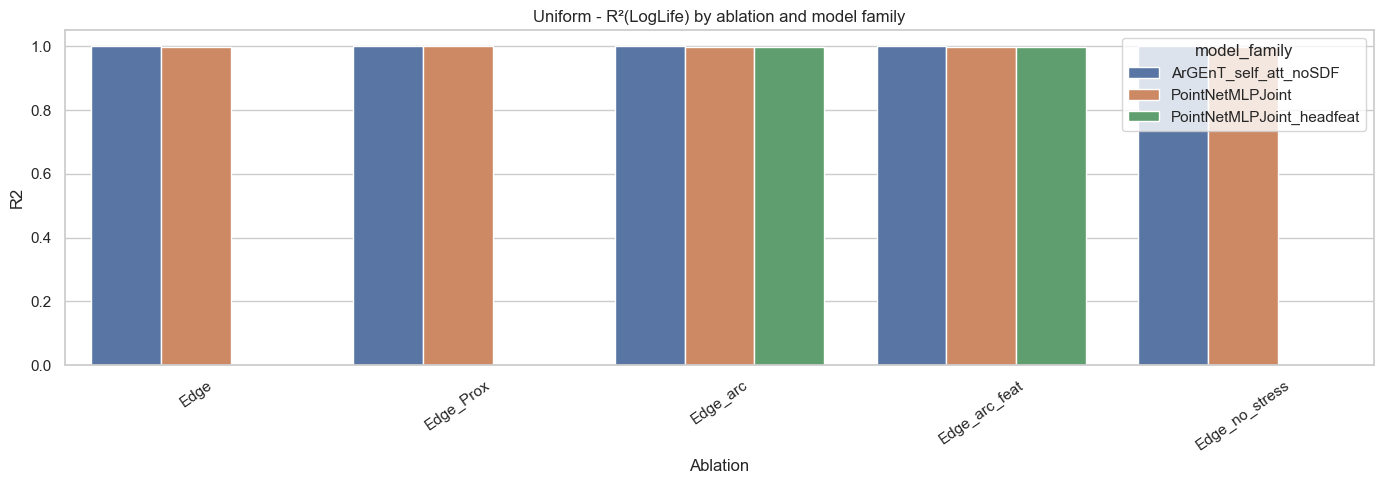

Saved: Comparison\figures\uniform_r2_loglife.png


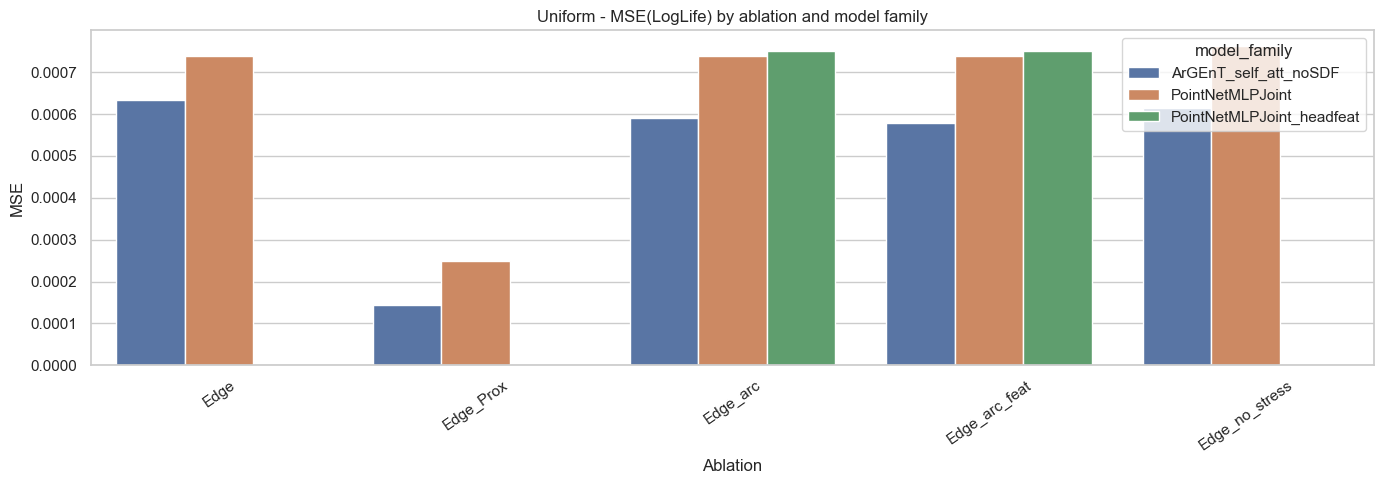

Saved: Comparison\figures\uniform_mse_loglife.png


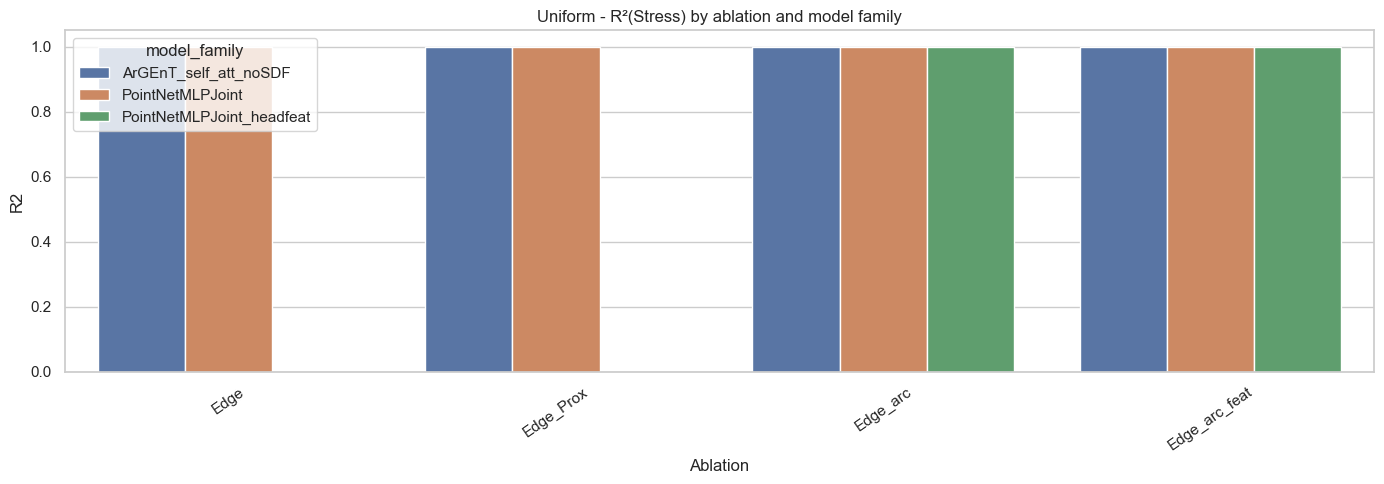

Saved: Comparison\figures\uniform_r2_stress.png


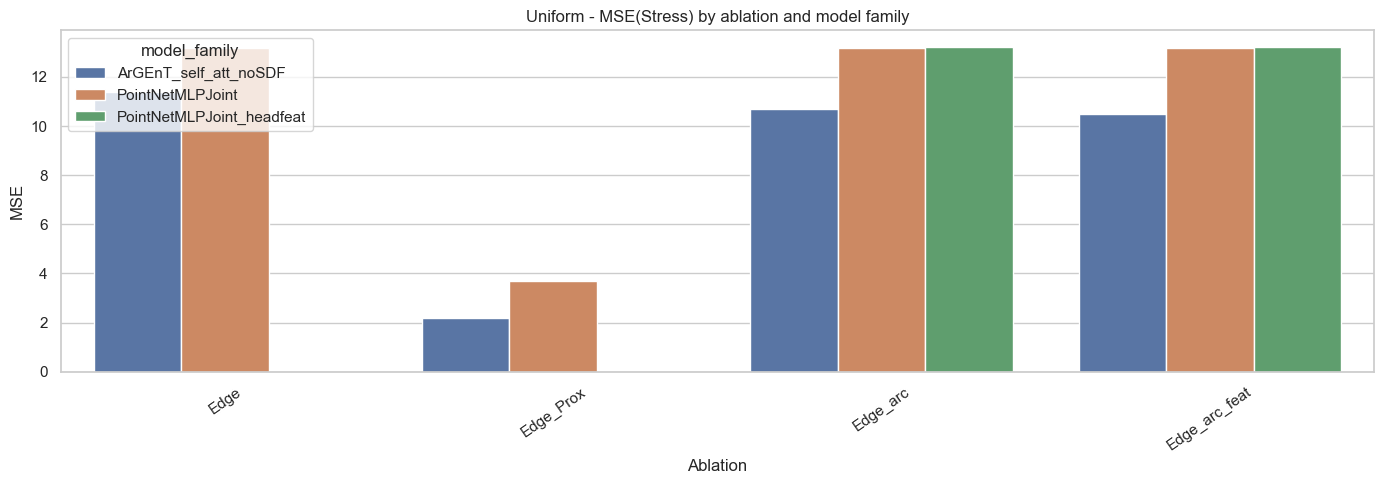

Saved: Comparison\figures\uniform_mse_stress.png


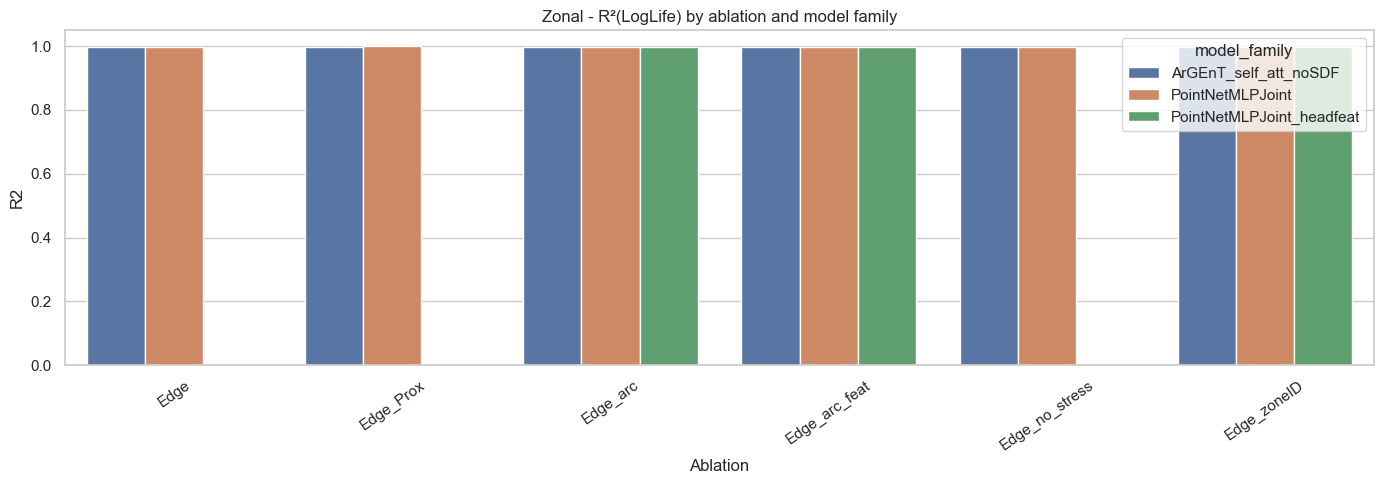

Saved: Comparison\figures\zonal_r2_loglife.png


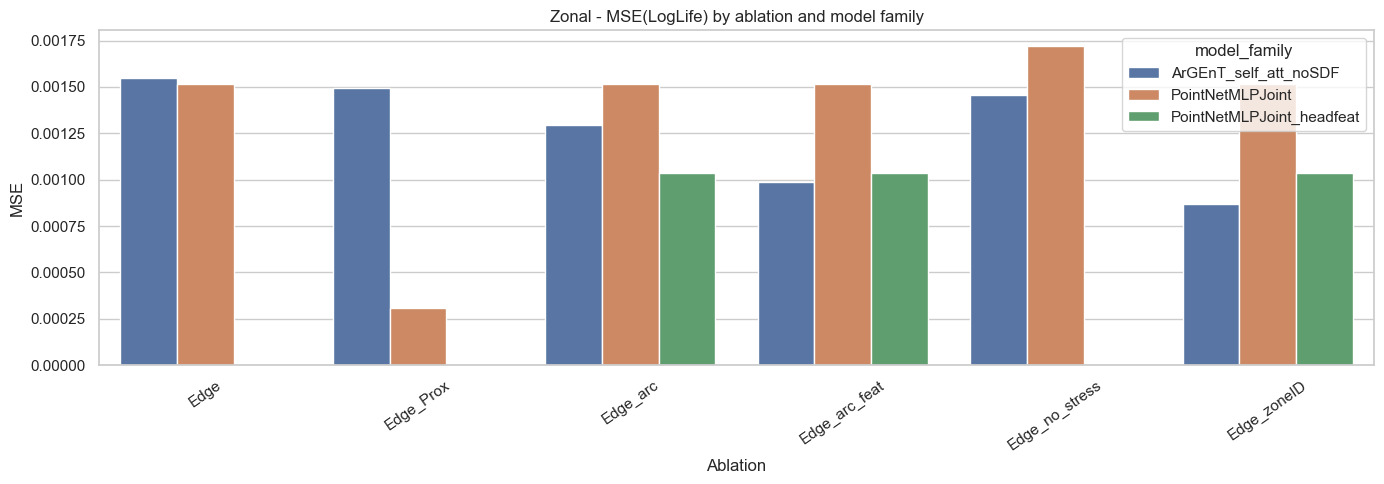

Saved: Comparison\figures\zonal_mse_loglife.png


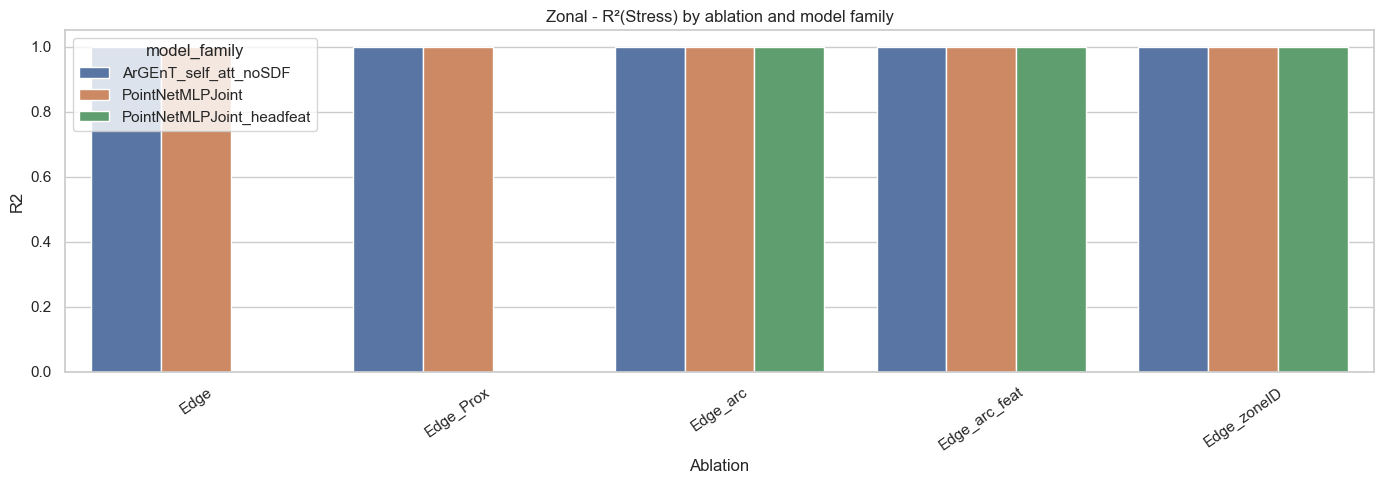

Saved: Comparison\figures\zonal_r2_stress.png


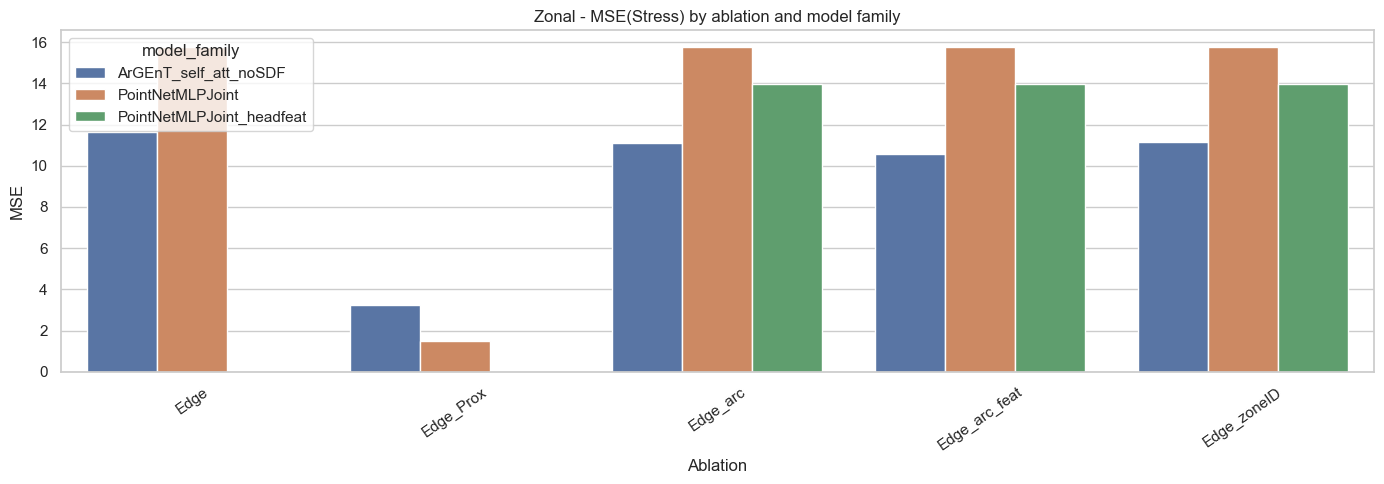

Saved: Comparison\figures\zonal_mse_stress.png


In [53]:
def barplot_metric(df: pd.DataFrame, target: str, metric: str, title: str, filename: str):
    d = df[df['target'] == target].copy()
    if d.empty:
        print(f'No data for {title}')
        return
    plt.figure(figsize=(14, 5))
    ax = sns.barplot(data=d, x='ablation', y=metric, hue='model_family')
    ax.set_title(title)
    ax.set_xlabel('Ablation')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    out = FIG_DIR / filename
    plt.savefig(out, dpi=180)
    plt.show()
    print(f'Saved: {out.relative_to(REPO_ROOT)}')

if metrics_long.empty:
    print('No metrics to plot in this runtime.')
else:
    for regime in ['Uniform','Zonal']:
        sub = metrics_long[metrics_long['regime'] == regime]
        if sub.empty:
            continue
        barplot_metric(sub, 'LogLife', 'R2', f'{regime} - R²(LogLife) by ablation and model family', f'{regime.lower()}_r2_loglife.png')
        barplot_metric(sub, 'LogLife', 'MSE', f'{regime} - MSE(LogLife) by ablation and model family', f'{regime.lower()}_mse_loglife.png')
        if 'Stress' in set(sub['target']):
            barplot_metric(sub, 'Stress', 'R2', f'{regime} - R²(Stress) by ablation and model family', f'{regime.lower()}_r2_stress.png')
            barplot_metric(sub, 'Stress', 'MSE', f'{regime} - MSE(Stress) by ablation and model family', f'{regime.lower()}_mse_stress.png')


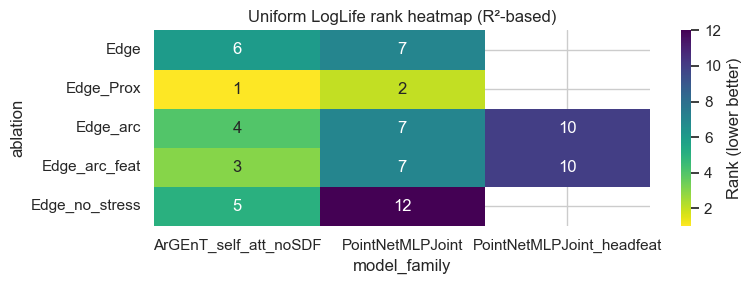

Saved: Comparison\figures\uniform_rank_heatmap_loglife.png


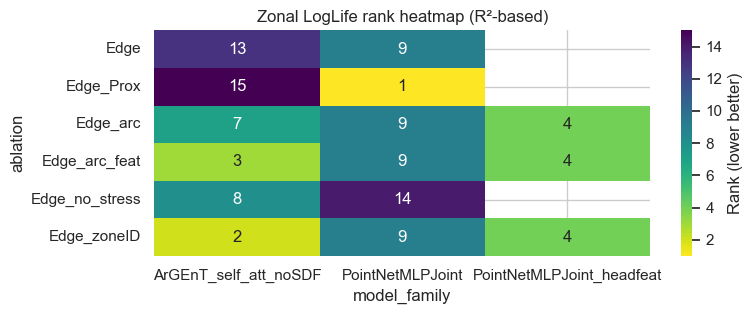

Saved: Comparison\figures\zonal_rank_heatmap_loglife.png


In [54]:
if ranked_df.empty:
    print('No ranked data for heatmap.')
else:
    for regime in ['Uniform','Zonal']:
        sub = ranked_df[(ranked_df['regime'] == regime) & (ranked_df['target'] == 'LogLife')]
        if sub.empty:
            continue
        pivot = sub.pivot_table(index='ablation', columns='model_family', values='rank_R2_within_regime_target', aggfunc='mean')
        plt.figure(figsize=(8, max(3, 0.55 * len(pivot))))
        sns.heatmap(pivot, annot=True, cmap='viridis_r', cbar_kws={'label':'Rank (lower better)'})
        plt.title(f'{regime} LogLife rank heatmap (R²-based)')
        plt.tight_layout()
        out = FIG_DIR / f'{regime.lower()}_rank_heatmap_loglife.png'
        plt.savefig(out, dpi=180)
        plt.show()
        print(f'Saved: {out.relative_to(REPO_ROOT)}')


## 8) Coverage and exclusions


In [55]:
cov_rows = []

for _, r in primary_df.iterrows():
    reason = None
    status = 'included'

    if not isinstance(r['primary_checkpoint_path'], str):
        status = 'excluded'
        reason = 'missing checkpoint'
    else:
        m = eval_df[(eval_df['regime']==r['regime']) & (eval_df['ablation']==r['ablation']) & (eval_df['model_family']==r['model_family'])]
        if m.empty:
            status = 'excluded'
            reason = 'no evaluation row produced'
        elif not bool(m.iloc[0]['evaluation_ok']):
            status = 'excluded'
            reason = m.iloc[0]['evaluation_error']

    cov_rows.append({
        'regime': r['regime'],
        'ablation': r['ablation'],
        'model_family': r['model_family'],
        'preset': r['preset'],
        'checkpoint': r['primary_checkpoint_path'],
        'status': status,
        'reason': reason,
    })

coverage_exclusions_df = pd.DataFrame(cov_rows).sort_values(['regime','ablation','model_family'])
coverage_exclusions_df


,regime,ablation,model_family,preset,checkpoint,status,reason
0,Uniform,Edge,ArGEnT_self_att_noSDF,S,Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,included,NaN
1,Uniform,Edge,PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,included,NaN
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,S,Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,included,NaN
3,Uniform,Edge_Prox,PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge_Prox\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_25b849a3.pt,included,NaN
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,S,Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,included,NaN
5,Uniform,Edge_arc,PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,included,NaN
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,S_full_ln_pos8,Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,included,NaN
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,S,Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt,included,NaN
8,Uniform,Edge_arc_feat,PointNetMLPJoint,S_full_ln_pos8,Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos8_242ec847.pt,included,NaN
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,S_full_ln_pos8,Uniform\Edge_arc_feat\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos8_76cc6623.pt,included,NaN


In [56]:
# Explicit Full variant reporting
full_rows = coverage_exclusions_df[coverage_exclusions_df['ablation'].str.lower() == 'full']
if full_rows.empty:
    print('No Full directories discovered for target families.')
else:
    full_rows


## 9) Final interpretation (direct, no fluff)


In [57]:
if metrics_long.empty:
    print('Interpretation is limited: no metrics were computed in this runtime.')
    print('- Most likely blocker: missing runtime dependencies (torch/h5py) and/or missing Data_gen/output/*.h5 datasets.')
    print('- Coverage table above lists exactly what was excluded and why.')
else:
    # Winners by regime+target
    winners = ranked_df.sort_values(['regime','target','rank_R2_within_regime_target','MSE']).groupby(['regime','target'], as_index=False).first()

    print('Winners (by best R², tie-breaker lower MSE):')
    display(winners[['regime','target','model_family','ablation','R2','MSE']])

    # headfeat effect
    pn = ranked_df[ranked_df['model_family'] == 'PointNetMLPJoint']
    hf = ranked_df[ranked_df['model_family'] == 'PointNetMLPJoint_headfeat']
    pn_hf_comp = pn.merge(hf, on=['regime','ablation','target'], suffixes=('_pn','_hf'))
    if pn_hf_comp.empty:
        print('No direct evaluated overlap to quantify headfeat gain/loss.')
    else:
        d = pn_hf_comp.groupby(['regime','target']).agg(
            mean_delta_R2=('R2_hf', lambda s: float(np.mean(s - pn_hf_comp.loc[s.index, 'R2_pn']))),
            mean_delta_MSE=('MSE_hf', lambda s: float(np.mean(s - pn_hf_comp.loc[s.index, 'MSE_pn']))),
            n=('R2_hf','size')
        ).reset_index()
        print('Headfeat effect (_headfeat minus PointNetMLPJoint):')
        display(d)

    # ArGEnT competitiveness
    arg = ranked_df[ranked_df['model_family'] == 'ArGEnT_self_att_noSDF']
    non_arg = ranked_df[ranked_df['model_family'] != 'ArGEnT_self_att_noSDF']
    if not arg.empty and not non_arg.empty:
        best_non_arg = non_arg.sort_values(['regime','ablation','target','MSE']).groupby(['regime','ablation','target'], as_index=False).first()
        c = arg.merge(best_non_arg, on=['regime','ablation','target'], suffixes=('_arg','_best'))
        c['delta_R2'] = c['R2_arg'] - c['R2_best']
        c['delta_MSE'] = c['MSE_arg'] - c['MSE_best']
        print('ArGEnT competitiveness vs best non-ArGEnT (positive delta_R2 is better, negative delta_MSE is better):')
        display(c[['regime','ablation','target','model_family_best','delta_R2','delta_MSE']].sort_values(['regime','target','ablation']))

    excl = coverage_exclusions_df[coverage_exclusions_df['status'] != 'included']
    if not excl.empty:
        print('Not comparable / excluded entries:')
        display(excl[['regime','ablation','model_family','reason']])


Winners (by best R², tie-breaker lower MSE):


,regime,target,model_family,ablation,R2,MSE
0,Uniform,LogLife,ArGEnT_self_att_noSDF,Edge_Prox,0.999769,0.000144
1,Uniform,Stress,ArGEnT_self_att_noSDF,Edge_Prox,0.999757,2.194126
2,Zonal,LogLife,PointNetMLPJoint,Edge_Prox,0.999269,0.000309
3,Zonal,Stress,PointNetMLPJoint,Edge_Prox,0.999834,1.503363


Headfeat effect (_headfeat minus PointNetMLPJoint):


,regime,target,mean_delta_R2,mean_delta_MSE,n
0,Uniform,LogLife,-0.000013,0.000012,2
1,Uniform,Stress,-0.000005,0.064156,2
2,Zonal,LogLife,0.000935,-0.000481,3
3,Zonal,Stress,0.000131,-1.833830,3


ArGEnT competitiveness vs best non-ArGEnT (positive delta_R2 is better, negative delta_MSE is better):


,regime,ablation,target,model_family_best,delta_R2,delta_MSE
1,Uniform,Edge,LogLife,PointNetMLPJoint,0.000112,-0.000105
3,Uniform,Edge_Prox,LogLife,PointNetMLPJoint,0.000168,-0.000105
5,Uniform,Edge_arc,LogLife,PointNetMLPJoint,0.000158,-0.000148
7,Uniform,Edge_arc_feat,LogLife,PointNetMLPJoint,0.000171,-0.000161
8,Uniform,Edge_no_stress,LogLife,PointNetMLPJoint,0.000157,-0.000147
0,Uniform,Edge,Stress,PointNetMLPJoint,0.000127,-1.777817
2,Uniform,Edge_Prox,Stress,PointNetMLPJoint,0.000165,-1.489450
4,Uniform,Edge_arc,Stress,PointNetMLPJoint,0.000177,-2.488899
6,Uniform,Edge_arc_feat,Stress,PointNetMLPJoint,0.000191,-2.677065
10,Zonal,Edge,LogLife,PointNetMLPJoint,-0.000064,0.000033


Not comparable / excluded entries:


,regime,ablation,model_family,reason
12,Uniform,Full,ArGEnT_self_att_noSDF,missing checkpoint
13,Uniform,Full,PointNetMLPJoint,missing checkpoint
29,Zonal,Full,ArGEnT_self_att_noSDF,missing checkpoint
30,Zonal,Full,PointNetMLPJoint,missing checkpoint
